In [ ]:
import sys
sys.path.append("..")
from functions import bbo_n
import numpy as np
import matplotlib.pyplot as plt

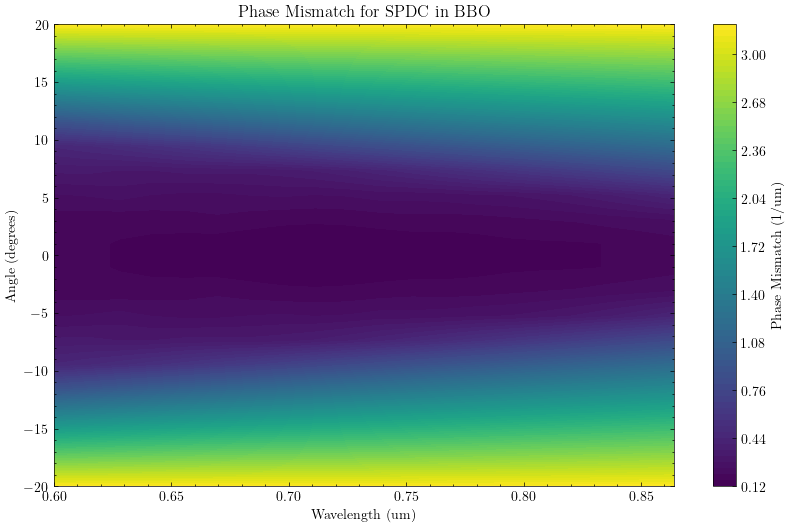

In [51]:
pump_wl = 1.064 # pump wavelength in um
wl_arr = np.linspace(0.6, pump_wl-0.2, 20) # array of wavelengths for signal and idler
angle_arr = np.linspace(-20, 20, 20) # array of angles in degrees for phase matching
#WL, ANGLE = np.meshgrid(wl_arr, angle_arr) # create a meshgrid for wavelengths and angles
np_o, np_e = bbo_n(pump_wl)
delta_k_arr = np.zeros((len(angle_arr), len(wl_arr))) # initialize array to store phase mismatch values
pump_sng = 0
kpx_o, kpz_o = np_o * 2 * np.pi / pump_wl * np.sin(np.radians(pump_sng)), np_o * 2 * np.pi / pump_wl * np.cos(np.radians(pump_sng)) # pump wavevector components for ordinary polarization
kpx_e, kpz_e = np_e * 2 * np.pi / pump_wl * np.sin(np.radians(pump_sng)), np_e * 2 * np.pi / pump_wl * np.cos(np.radians(pump_sng)) # pump wavevector components for extraordinary polarization
for i in range(len(wl_arr)):
    for j in range(len(angle_arr)):
        delta_k_min = np.inf
        for k in range(len(angle_arr)):
            wl1 = wl_arr[i]
            angle_1 = angle_arr[j]
            n1_o, n1_e = bbo_n(wl1)
            k1x_o, k1z_o = n1_o * 2 * np.pi / wl1 * np.sin(np.radians(angle_1)), n1_o * 2 * np.pi / wl1 * np.cos(np.radians(angle_1)) # signal wavevector components for ordinary polarization
            k1x_e, k1z_e = n1_e * 2 * np.pi / wl1 * np.sin(np.radians(angle_1)), n1_e * 2 * np.pi / wl1 * np.cos(np.radians(angle_1)) # signal wavevector components for extraordinary polarization
            wl2 = 1 / (1/pump_wl - 1/wl1) # calculate idler wavelength using energy conservation
            n2_o, n2_e = bbo_n(wl2)
            angle_2 = angle_arr[k]
            k2x_o, k2z_o = n2_o * 2 * np.pi / wl2 * np.sin(np.radians(angle_2)), n2_o * 2 * np.pi / wl2 * np.cos(np.radians(angle_2)) # idler wavevector components for ordinary polarization
            k2x_e, k2z_e = n2_e * 2 * np.pi / wl2 * np.sin(np.radians(angle_2)), n2_e * 2 * np.pi / wl2 * np.cos(np.radians(angle_2)) # idler wavevector components for extraordinary polarization
            # Calculate phase mismatch for ordinary and extraordinary polarizations
            delta_k1 = np.sqrt((kpx_o - k1x_e - k2x_e)**2 + (kpz_o - k1z_e - k2z_e)**2) # phase mismatch for ordinary
            delta_k2 = np.sqrt((kpx_e - k1x_o - k2x_o)**2 + (kpz_e - k1z_o - k2z_o)**2) # phase mismatch for ordinarypolarization
            delta_k3 = np.sqrt((kpx_o - k1x_o - k2x_o)**2 + (kpz_o - k1z_o - k2z_o)**2) # phase mismatch for extraordinary polarization
            delta_k4 = np.sqrt((kpx_e - k1x_e - k2x_e)**2 + (kpz_e - k1z_e - k2z_e)**2) # phase mismatch for extraordinary polarization
            if delta_k4 < delta_k_min:
                delta_k_min = delta_k4
        delta_k_arr[j, i] = delta_k_min # store phase mismatch value in array
# Plot phase mismatch as a function of wavelength and angle
plt.figure(figsize=(10, 6))
plt.contourf( wl_arr, angle_arr, delta_k_arr, levels=100)#, cmap='viridis')
plt.colorbar(label='Phase Mismatch (1/um)')
plt.ylabel('Angle (degrees)')
plt.xlabel('Wavelength (um)')
plt.title('Phase Mismatch for SPDC in BBO')
plt.show()